In [1]:
# Uncomment these in a fresh notebook environment.
# %pip install -r ../requirements.txt
# %pip install -e ..

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt

GREEN_PHASE_COUNT = 2

def print_comparison_table(rows):
    columns = [
        "Policy",
        "Episodes",
        "Mean total reward",
        "Mean local queue",
        "Total completed steps",
        "Mean switches / episode",
    ]

    def format_value(value):
        if isinstance(value, float):
            return f"{value:.3f}"
        return str(value)

    widths = {column: len(column) for column in columns}
    for row in rows:
        for column in columns:
            widths[column] = max(widths[column], len(format_value(row.get(column, ""))))

    header = " | ".join(column.ljust(widths[column]) for column in columns)
    separator = "-+-".join("-" * widths[column] for column in columns)
    print(header)
    print(separator)
    for row in rows:
        print(" | ".join(format_value(row.get(column, "")).ljust(widths[column]) for column in columns))


In [3]:
from marl_tsc.simulation_generator import SimulationGenerator, DEFAULT_TRAFFIC_LIGHT_IDS
from marl_tsc.training import train_ppo, evaluate_policy, plot_training_histories
from marl_tsc.mappo import train_mappo
from marl_tsc.baselines import random_actions, fixed_time_actions


## 1. Generate the SUMO simulation files

This default setup is a small `4x4` grid with four traffic-light agents. Change these values first when you want a different learning problem.


In [4]:
NOTEBOOK_DIR = Path.cwd().resolve()
PROJECT_ROOT = NOTEBOOK_DIR.parent if (NOTEBOOK_DIR / "main_flow.ipynb").exists() else NOTEBOOK_DIR
OUTPUT_DIR = PROJECT_ROOT / "outputs"

traffic_light_ids = list(DEFAULT_TRAFFIC_LIGHT_IDS)

generator = SimulationGenerator(
    output_dir=OUTPUT_DIR,
    grid_number=4,
    lane_number=1,
    traffic_light_ids=traffic_light_ids,
    trip_begin=0,
    trip_end=1000,
    trip_period=2,
    seed=42,
)

paths = generator.generate_all()
print("Generated:", paths.config_file)
print("Traffic-light agents:", traffic_light_ids)


Generated: C:\Code\marl-tsc\outputs\config.sumocfg
Traffic-light agents: ['B1', 'B2', 'C1', 'C2']


## 2. Run the simple baselines

Random and fixed-time are useful sanity checks before training. They use the same environment and the same evaluation seeds as the learned policies.


In [5]:
random_result = evaluate_policy(
    config_file=paths.config_file,
    traffic_light_ids=traffic_light_ids,
    policy=random_actions,
    episodes=3,
    max_steps=1000,
    seed=42,
    env_kwargs={"green_phase_count": GREEN_PHASE_COUNT},
)

fixed_time_result = evaluate_policy(
    config_file=paths.config_file,
    traffic_light_ids=traffic_light_ids,
    policy=fixed_time_actions,
    episodes=3,
    max_steps=1000,
    seed=42,
    env_kwargs={"green_phase_count": GREEN_PHASE_COUNT},
)

baseline_rows = [
    {
        "Policy": "Random",
        "Episodes": random_result["episodes"],
        "Mean total reward": random_result["mean_total_reward"],
        "Mean local queue": random_result["mean_local_queue"],
        "Total completed steps": random_result["total_completed_steps"],
        "Mean switches / episode": random_result["mean_switches_per_episode"],
    },
    {
        "Policy": "Fixed time",
        "Episodes": fixed_time_result["episodes"],
        "Mean total reward": fixed_time_result["mean_total_reward"],
        "Mean local queue": fixed_time_result["mean_local_queue"],
        "Total completed steps": fixed_time_result["total_completed_steps"],
        "Mean switches / episode": fixed_time_result["mean_switches_per_episode"],
    },
]

print_comparison_table(baseline_rows)


Policy     | Episodes | Mean total reward | Mean local queue | Total completed steps | Mean switches / episode
-----------+----------+-------------------+------------------+-----------------------+------------------------
Random     | 3        | -311.733          | 0.296            | 695                   | 307.333                
Fixed time | 3        | -191.567          | 0.190            | 644                   | 284.000                


## 3. Train

PPO uses parameter sharing through the PettingZoo/SuperSuit/SB3 wrapper. MAPPO adds a centralized critic and a shared decentralized actor.


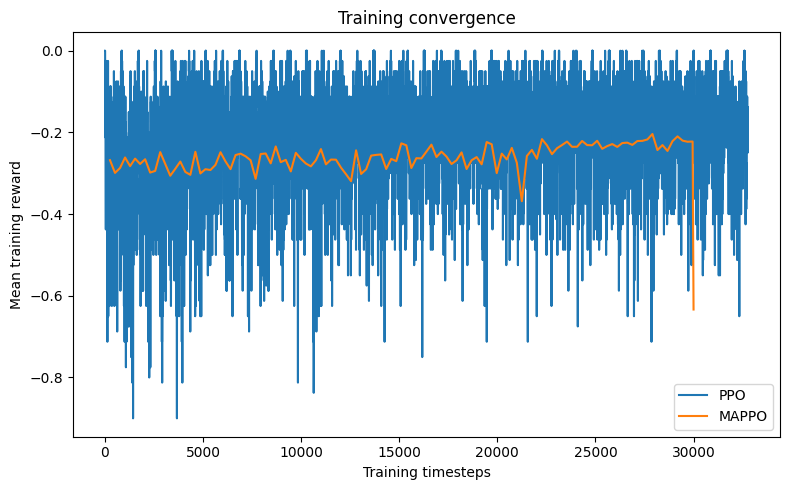

Saved PPO model: C:\Code\marl-tsc\outputs\ppo_sumo_traffic.zip
Saved MAPPO model: C:\Code\marl-tsc\outputs\models\mappo.pt


In [6]:
ppo_model, ppo_history, ppo_model_path = train_ppo(
    config_file=paths.config_file,
    traffic_light_ids=traffic_light_ids,
    output_dir=OUTPUT_DIR,
    total_timesteps=30_000,
    max_steps=1000,
    seed=42,
    env_kwargs={"green_phase_count": GREEN_PHASE_COUNT},
)

mappo_model, mappo_history, mappo_model_path = train_mappo(
    config_file=paths.config_file,
    traffic_light_ids=traffic_light_ids,
    output_dir=OUTPUT_DIR,
    total_timesteps=30_000,
    rollout_steps=256,
    max_steps=1000,
    seed=42,
    env_kwargs={"green_phase_count": GREEN_PHASE_COUNT},
)

fig, ax = plot_training_histories(ppo_history + mappo_history)
plt.show()

print("Saved PPO model:", ppo_model_path)
print("Saved MAPPO model:", mappo_model_path)


## 4. Evaluate all policies on the same seeds

The final comparison table keeps the baseline runs and adds the shared PPO and MAPPO policies on the same evaluation seeds.


In [7]:
shared_ppo_result = evaluate_policy(
    config_file=paths.config_file,
    traffic_light_ids=traffic_light_ids,
    policy=ppo_model,
    episodes=3,
    max_steps=1000,
    seed=42,
    env_kwargs={"green_phase_count": GREEN_PHASE_COUNT},
)

shared_mappo_result = evaluate_policy(
    config_file=paths.config_file,
    traffic_light_ids=traffic_light_ids,
    policy=mappo_model,
    episodes=3,
    max_steps=1000,
    seed=42,
    env_kwargs={"green_phase_count": GREEN_PHASE_COUNT},
)

comparison_rows = baseline_rows + [
    {
        "Policy": "Shared PPO",
        "Episodes": shared_ppo_result["episodes"],
        "Mean total reward": shared_ppo_result["mean_total_reward"],
        "Mean local queue": shared_ppo_result["mean_local_queue"],
        "Total completed steps": shared_ppo_result["total_completed_steps"],
        "Mean switches / episode": shared_ppo_result["mean_switches_per_episode"],
    },
    {
        "Policy": "MAPPO",
        "Episodes": shared_mappo_result["episodes"],
        "Mean total reward": shared_mappo_result["mean_total_reward"],
        "Mean local queue": shared_mappo_result["mean_local_queue"],
        "Total completed steps": shared_mappo_result["total_completed_steps"],
        "Mean switches / episode": shared_mappo_result["mean_switches_per_episode"],
    },
]

print_comparison_table(comparison_rows)


Policy     | Episodes | Mean total reward | Mean local queue | Total completed steps | Mean switches / episode
-----------+----------+-------------------+------------------+-----------------------+------------------------
Random     | 3        | -311.733          | 0.296            | 695                   | 307.333                
Fixed time | 3        | -191.567          | 0.190            | 644                   | 284.000                
Shared PPO | 3        | -175.083          | 0.154            | 644                   | 426.667                
MAPPO      | 3        | -175.083          | 0.154            | 644                   | 426.667                
